In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from econml.dml import LinearDML

In [39]:
df = pd.read_csv('../data/ihdp_data.csv', header=0)
df.head()

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,True,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,False,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,False,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,False,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,False,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


## Explore data

In [40]:
#μ₀ (mu0) → true outcome if a patient did NOT receive treatment
#μ₁ (mu1) → true outcome if a patient DID receive treatment
#y_factual = either mu0 or mu1 (depending on treatment)
#y_cfactual = the unobserved count erfactual

print(f'Shape of the data {df.shape}\n')
#print(f'missing value count {X.notna().sum()}')
print(f'Treatment balance {df.treatment.value_counts()}\n')

y_factual_mean = df.groupby('treatment')['y_factual'].mean()
y_cfactual_mean = df.groupby('treatment')['y_cfactual'].mean()

print(f'mean factual outcome by class {y_factual_mean} \n')
print(f'mean counter factual outcome by class {y_cfactual_mean} \n')

# calculate true ite 
true_ite = df["mu1"] - df["mu0"]
print(f'True average treatment effect {true_ite.mean()}')


Shape of the data (747, 30)

Treatment balance treatment
False    608
True     139
Name: count, dtype: int64

mean factual outcome by class treatment
False    2.411297
True     6.432418
Name: y_factual, dtype: float64 

mean counter factual outcome by class treatment
False    6.444993
True     2.420404
Name: y_cfactual, dtype: float64 

True average treatment effect 4.016066896118338


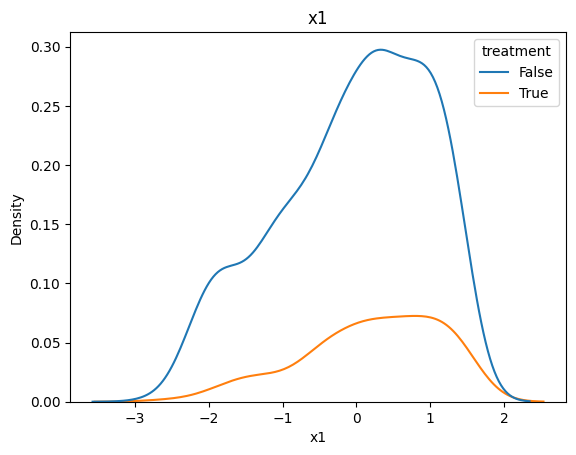

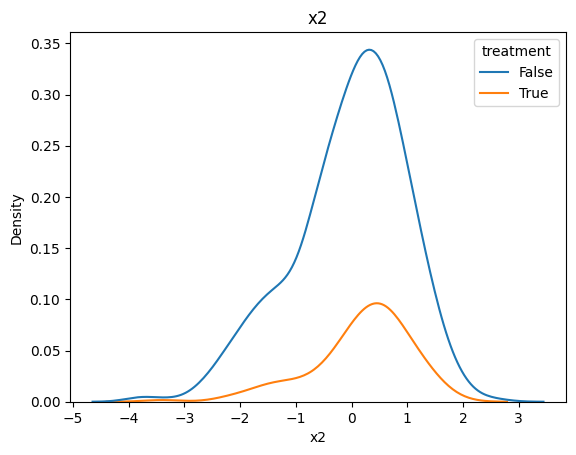

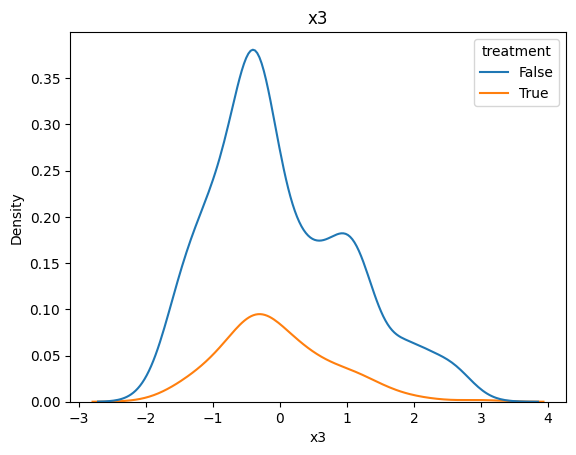

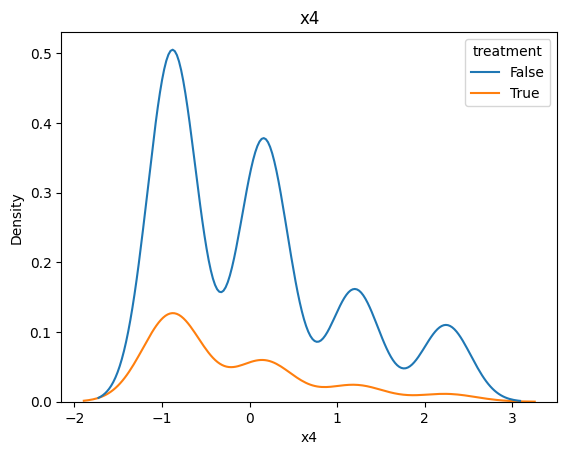

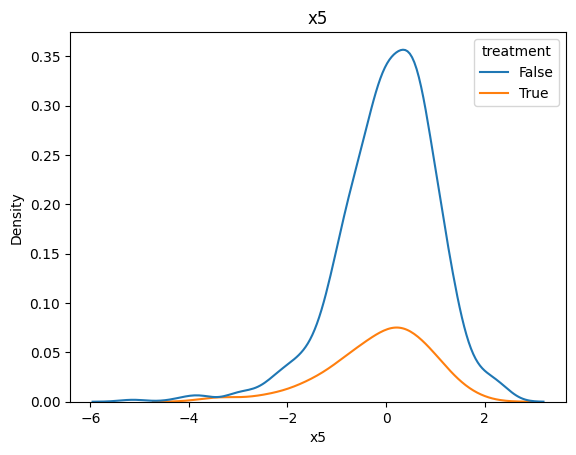

In [41]:

# check Covariate balance. how feature xi is distributed for treated vs control groups.
for col in df.columns[5:10]:  
    sns.kdeplot(data=df, x=col, hue="treatment")
    plt.title(col)
    plt.show()

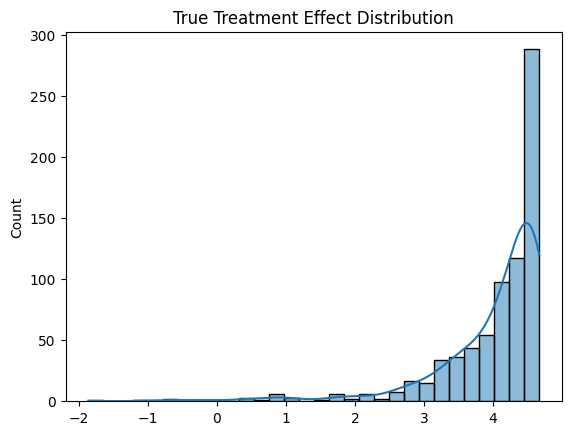

In [42]:
# visualize heterogeneity

sns.histplot(true_ite, bins=30, kde=True)
plt.title("True Treatment Effect Distribution")
plt.show()

# Most values are positive - treatment is generally beneficial

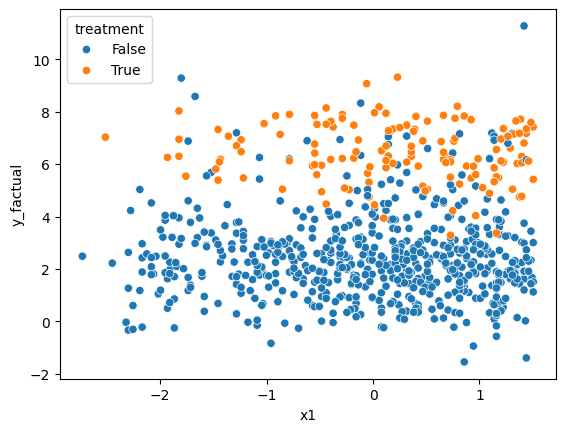

In [43]:
sns.scatterplot(x=df["x1"], y=df["y_factual"], hue=df["treatment"])
plt.show()

### Naive estimate

In [44]:
# True ATE
true_ate = (df["mu1"] - df["mu0"]).mean()

# Naive ATE
naive_ate = df[df["treatment"]==1]["y_factual"].mean() - df[df["treatment"]==0]["y_factual"].mean()

print("Naive ATE:", naive_ate)
print("True ATE:", true_ate)


Naive ATE: 4.021121012430829
True ATE: 4.016066896118338


## Estimating Treatment Effects with Double Machine Learning 

In [45]:
T = df['treatment']
Y = df['y_factual']
X = df.drop(['treatment', 'y_factual', 'y_cfactual', 'mu0', 'mu1'], axis = 1)

# split data
X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(X, T, Y, test_size=0.3, random_state=42)



In [46]:
true_ite_test = true_ite[X_test.index] 
true_ite_train = true_ite[X_train.index] 


In [65]:
# Separate continuous and binary columns
continuous_cols = X_train.select_dtypes(include=["float", "float64"]).columns.tolist()

binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]

scaler = StandardScaler()

X_train_cont_scaled = scaler.fit_transform(X_train[continuous_cols])
X_test_cont_scaled = scaler.transform(X_test[continuous_cols])

# Convert scaled arrays back to DataFrames
X_train_cont_scaled = pd.DataFrame(
    X_train_cont_scaled,
    columns=continuous_cols,
    index=X_train.index
)

X_test_cont_scaled = pd.DataFrame(
    X_test_cont_scaled,
    columns=continuous_cols,
    index=X_test.index
)

# Combine scaled continuous features with unscaled binary features
X_train_processed = pd.concat(
    [X_train_cont_scaled, X_train[binary_cols]],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_cont_scaled, X_test[binary_cols]],
    axis=1
)

# Ensure same column order
X_test_processed = X_test_processed[X_train_processed.columns]

X_train_processed.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
382,-2.050773,-2.189401,1.493748,1.167183,-0.203501,0.151441,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0
423,-0.120995,-0.178484,-1.110333,-0.877346,0.510307,-0.685975,1,0,0,1,...,1,1,1,0,0,0,0,1,0,0
176,-0.892906,-0.982850,1.121736,0.144919,-1.306659,-1.355908,1,0,0,1,...,1,0,1,0,1,0,0,0,0,0
500,0.843894,0.625883,-1.110333,0.144919,0.899656,-1.690875,1,0,0,1,...,1,0,1,0,0,0,0,0,1,0
640,-0.163879,0.625883,-0.366310,-0.877346,-0.333284,0.318924,0,0,1,0,...,1,1,1,0,0,0,0,0,0,1


In [72]:
# fit DML
dml = LinearDML(
    model_y = RandomForestRegressor(n_estimators=100),
    model_t = RandomForestClassifier(n_estimators=100),
    discrete_treatment=True,
    cv=3,
    random_state=42
)

dml.fit(y_train, T_train, X = X_train_processed)

dml_ate = dml.ate(X_test)
dml_ite = dml.effect(X_test)

print("DML Average Treatment Effect:", dml_ate)

DML Average Treatment Effect: 4.022639258797313


In [95]:
print(f'Treatment distribution in test data: {T_test.value_counts()}')
# ATE error
ate_error = abs(dml_ate - true_ate)

pehe = np.sqrt(np.mean((dml_ite - true_ite_test)**2))

print("ATE error:", ate_error)
print("PEHE:", pehe)

print("True ATE:", true_ate)
print("Naive ATE:", naive_ate)
print("DML ATE:", dml_ate)

Treatment distribution in test data: treatment
False    185
True      40
Name: count, dtype: int64
ATE error: 0.006572362678975097
PEHE: 0.9282426382732942
True ATE: 4.016066896118338
Naive ATE: 4.021121012430829
DML ATE: 4.022639258797313


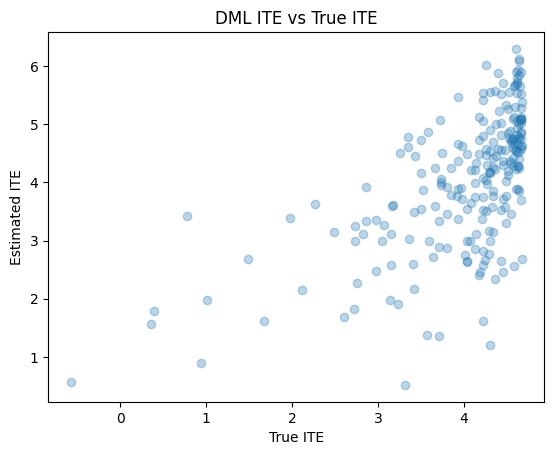

In [78]:
plt.scatter(true_ite_test, dml_ite, alpha=0.3)
plt.xlabel("True ITE")
plt.ylabel("Estimated ITE")
plt.title("DML ITE vs True ITE")
plt.show()

## Policy Evaluation

In [104]:
policy = (dml_ite > dml_ite.mean()).astype(int)

In [105]:
df_eval = pd.DataFrame({
    "T_actual": T_test,
    "T_policy": policy,
    "ITE": dml_ite
})

df_eval.head()

,T_actual,T_policy,ITE
208,False,0,3.928428
259,False,0,2.585139
97,False,1,4.248549
148,False,0,3.855248
395,False,1,4.257227


In [106]:
# evaluate policy  - 
mu0_test = df.loc[X_test.index, "mu0"]
mu1_test = df.loc[X_test.index, "mu1"]

# outcome under the policy
policy_outcome = policy * mu1_test + (1 - policy) * mu0_test

# outcome under observed treatment
observed_outcome = T_test * mu1_test + (1 - T_test) * mu0_test

print("Policy value:", policy_outcome.mean())
print("Observed value:", observed_outcome.mean())

Policy value: 4.883704117196387
Observed value: 3.1812722914497833


In [107]:
# compare policy
random_policy = np.random.binomial(1, 0.5, size=len(policy))
random_outcome = random_policy * mu1_test + (1 - random_policy) * mu0_test

print("Random policy value:", random_outcome.mean())

Random policy value: 4.692743355546657


In [108]:
treat_all = mu1_test.mean()
treat_none = mu0_test.mean()

print("Treat all:", treat_all)
print("Treat none:", treat_none)

Treat all: 6.456003175538252
Treat none: 2.4484548469094904


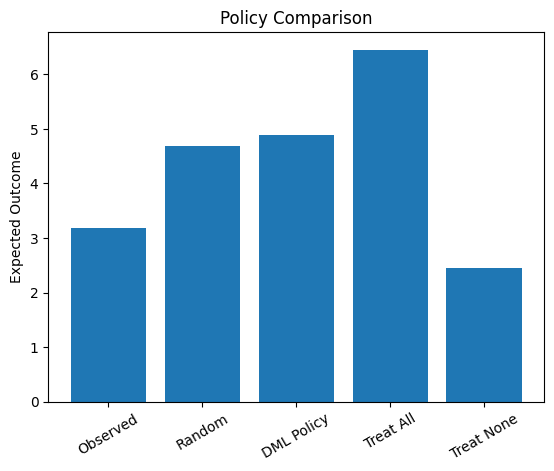

In [111]:
values = {
    "Observed": observed_outcome.mean(),
    "Random": random_outcome.mean(),
    "DML Policy": policy_outcome.mean(),
    "Treat All": treat_all,
    "Treat None": treat_none
}

plt.bar(values.keys(), values.values())
plt.xticks(rotation=30)
plt.ylabel("Expected Outcome")
plt.title("Policy Comparison")
plt.show()